# CIFAR-10 图像分类 — 基于卷积神经网络

## 实验概述
使用 PyTorch 构建 CNN 对 CIFAR-10 数据集（飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车）进行分类。


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
import random

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 随机种子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

OUTPUT_DIR = Path('output')
OUTPUT_DIR.mkdir(exist_ok=True)

# CIFAR-10 类别名
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
CLASS_NAMES_CN = ['飞机', '汽车', '鸟', '猫', '鹿',
                  '狗', '青蛙', '马', '船', '卡车']
NUM_CLASSES = 10
IMG_SIZE = 32
BATCH_SIZE = 64


Using device: cpu


## 1. 数据加载与探索

In [3]:
# 数据预处理定义
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2470, 0.2435, 0.2616])
])

# 下载 CIFAR-10 数据集
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# 从训练集中分出验证集 (训练 80% / 验证 20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'训练集: {train_size} | 验证集: {val_size} | 测试集: {len(test_dataset)}')
print(f'训练批次数: {len(train_loader)}')


训练集: 40000 | 验证集: 10000 | 测试集: 10000
训练批次数: 625


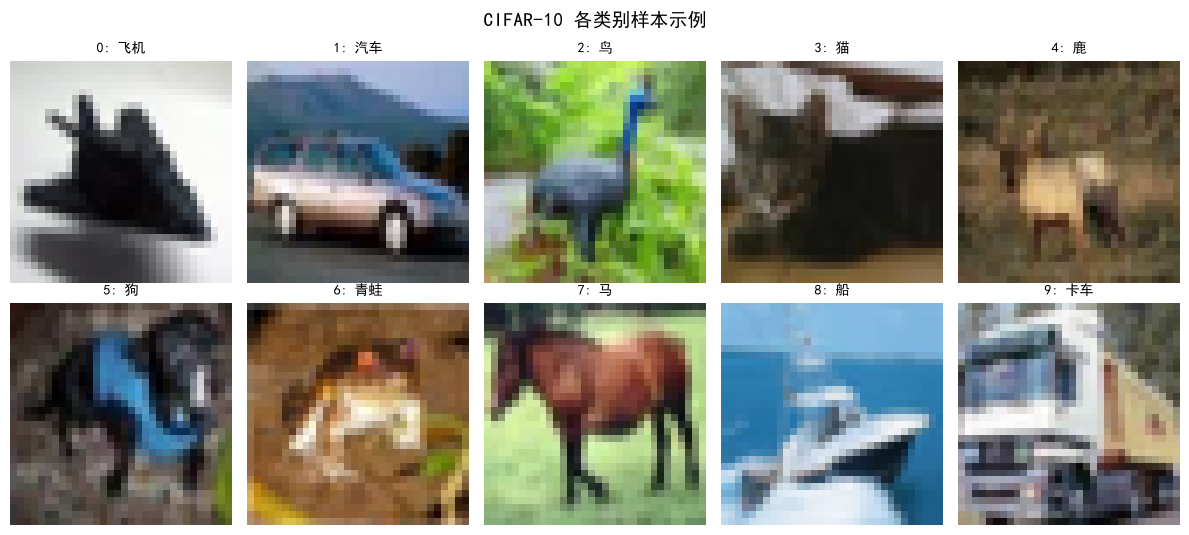

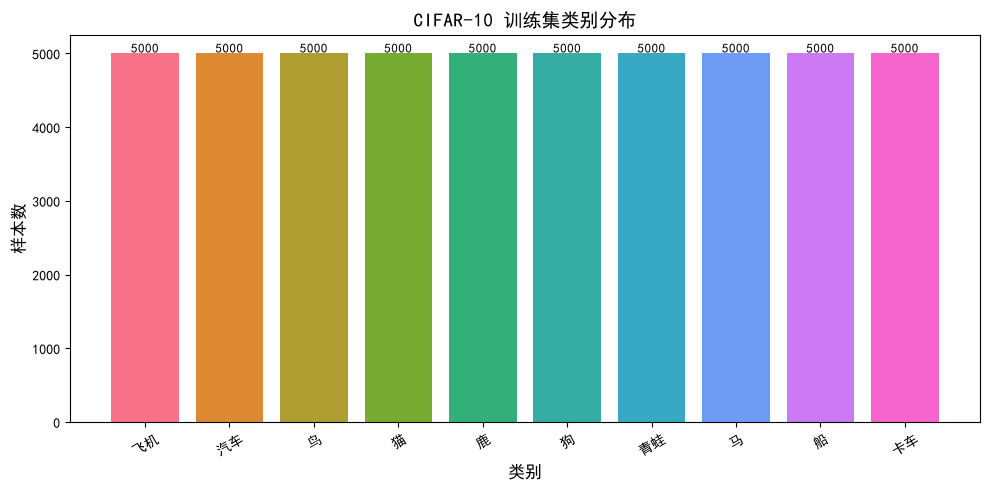

In [4]:
# 展示 CIFAR-10 样本图片
# 先加载未归一化的数据用于显示
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)

fig, axes = plt.subplots(2, 5, figsize=(12, 5.5))
axes = axes.flatten()
for i in range(10):
    # 找一张类别 i 的图
    idx = raw_train.targets.index(i)
    img, _ = raw_train[idx]
    axes[i].imshow(img)
    axes[i].set_title(f'{i}: {CLASS_NAMES_CN[i]}', fontsize=10)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 各类别样本示例', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# 类别分布
from collections import Counter
class_counts = Counter(raw_train.targets)
fig, ax = plt.subplots(figsize=(10, 5))
counts = [class_counts[i] for i in range(10)]
colors = sns.color_palette('husl', 10)
bars = ax.bar(CLASS_NAMES_CN, counts, color=colors)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontsize=9)
ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('样本数', fontsize=12)
ax.set_title('CIFAR-10 训练集类别分布', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. CNN 模型构建

In [5]:
class CIFAR10CNN(nn.Module):
    """CIFAR-10 分类 CNN

    架构:
    - Conv2d(3,32,3)+BatchNorm+ReLU+MaxPool(2)  -> 32x16x16
    - Conv2d(32,64,3)+BatchNorm+ReLU+MaxPool(2)  -> 64x8x8
    - Conv2d(64,128,3)+BatchNorm+ReLU+MaxPool(2) -> 128x4x4
    - FC(128*4*4, 256)+ReLU+Dropout(0.5)
    - FC(256, 10)
    """
    def __init__(self, num_classes=10):
        super(CIFAR10CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = CIFAR10CNN(NUM_CLASSES).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'总参数量: {total_params:,}')
print(f'可训练参数量: {trainable_params:,}')
print(model)


总参数量: 620,810
可训练参数量: 620,810
CIFAR10CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_

## 3. 模型训练

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)
NUM_EPOCHS = 50

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_model_state = None

print('开始训练...')
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{NUM_EPOCHS}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

print(f'\n训练完成! 最佳验证准确率: {best_val_acc:.4f}')
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), OUTPUT_DIR / 'model.pth')
    print('模型已保存到 output/model.pth')
else:
    print('警告: 未保存模型 (best_val_acc 始终为 0)')

开始训练...
Epoch [  1/50] Train Loss: 1.5004 | Train Acc: 0.4530 | Val Loss: 1.1445 | Val Acc: 0.5904
Epoch [  5/50] Train Loss: 0.9163 | Train Acc: 0.6816 | Val Loss: 0.8293 | Val Acc: 0.7050
Epoch [ 10/50] Train Loss: 0.7390 | Train Acc: 0.7458 | Val Loss: 0.6823 | Val Acc: 0.7627
Epoch [ 15/50] Train Loss: 0.6423 | Train Acc: 0.7791 | Val Loss: 0.6415 | Val Acc: 0.7784
Epoch [ 20/50] Train Loss: 0.5766 | Train Acc: 0.8027 | Val Loss: 0.5987 | Val Acc: 0.7948
Epoch [ 25/50] Train Loss: 0.5181 | Train Acc: 0.8217 | Val Loss: 0.6189 | Val Acc: 0.7932
Epoch [ 30/50] Train Loss: 0.4837 | Train Acc: 0.8334 | Val Loss: 0.5796 | Val Acc: 0.8054
Epoch [ 35/50] Train Loss: 0.4027 | Train Acc: 0.8598 | Val Loss: 0.5520 | Val Acc: 0.8194
Epoch [ 40/50] Train Loss: 0.3523 | Train Acc: 0.8767 | Val Loss: 0.5416 | Val Acc: 0.8274
Epoch [ 45/50] Train Loss: 0.3289 | Train Acc: 0.8853 | Val Loss: 0.5391 | Val Acc: 0.8302
Epoch [ 50/50] Train Loss: 0.3154 | Train Acc: 0.8891 | Val Loss: 0.5443 | Val Acc

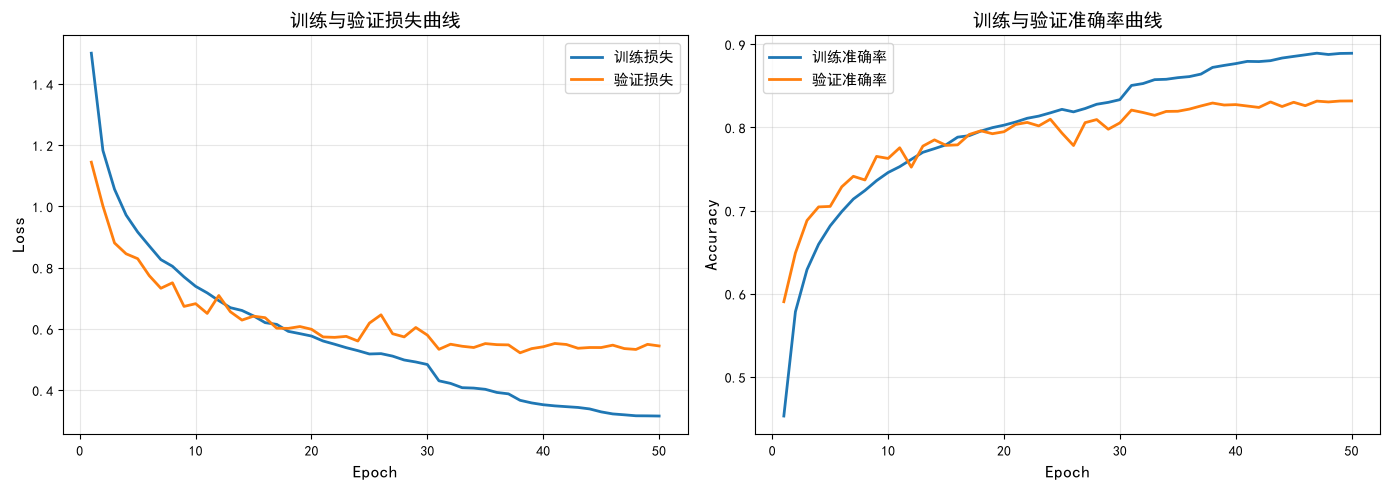

最终训练准确率: 0.8891
最终验证准确率: 0.8318
最佳验证准确率: 0.8318


In [7]:
# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, train_losses, label='训练损失', linewidth=2)
ax1.plot(epochs_range, val_losses, label='验证损失', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('训练与验证损失曲线', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, label='训练准确率', linewidth=2)
ax2.plot(epochs_range, val_accs, label='验证准确率', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('训练与验证准确率曲线', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'最终训练准确率: {train_accs[-1]:.4f}')
print(f'最终验证准确率: {val_accs[-1]:.4f}')
print(f'最佳验证准确率: {best_val_acc:.4f}')


## 4. 模型评估

In [8]:
# 测试集评估
model.eval()
all_preds = []
all_labels_true = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_true.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels_true = np.array(all_labels_true)

test_acc = (all_preds == all_labels_true).mean()
print(f'========== 测试集结果 ==========')
print(f'测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('\n分类报告:')
print(classification_report(all_labels_true, all_preds,
      target_names=CLASS_NAMES_CN, digits=4))


========== 测试集结果 ==========
测试集准确率: 0.8371 (83.71%)

分类报告:
              precision    recall  f1-score   support

          飞机     0.8362    0.8630    0.8494      1000
          汽车     0.9225    0.9170    0.9198      1000
           鸟     0.7797    0.7680    0.7738      1000
           猫     0.6794    0.6910    0.6852      1000
           鹿     0.8223    0.8330    0.8276      1000
           狗     0.7704    0.7450    0.7575      1000
          青蛙     0.8853    0.8720    0.8786      1000
           马     0.8740    0.8810    0.8775      1000
           船     0.9034    0.9070    0.9052      1000
          卡车     0.8985    0.8940    0.8962      1000

    accuracy                         0.8371     10000
   macro avg     0.8372    0.8371    0.8371     10000
weighted avg     0.8372    0.8371    0.8371     10000



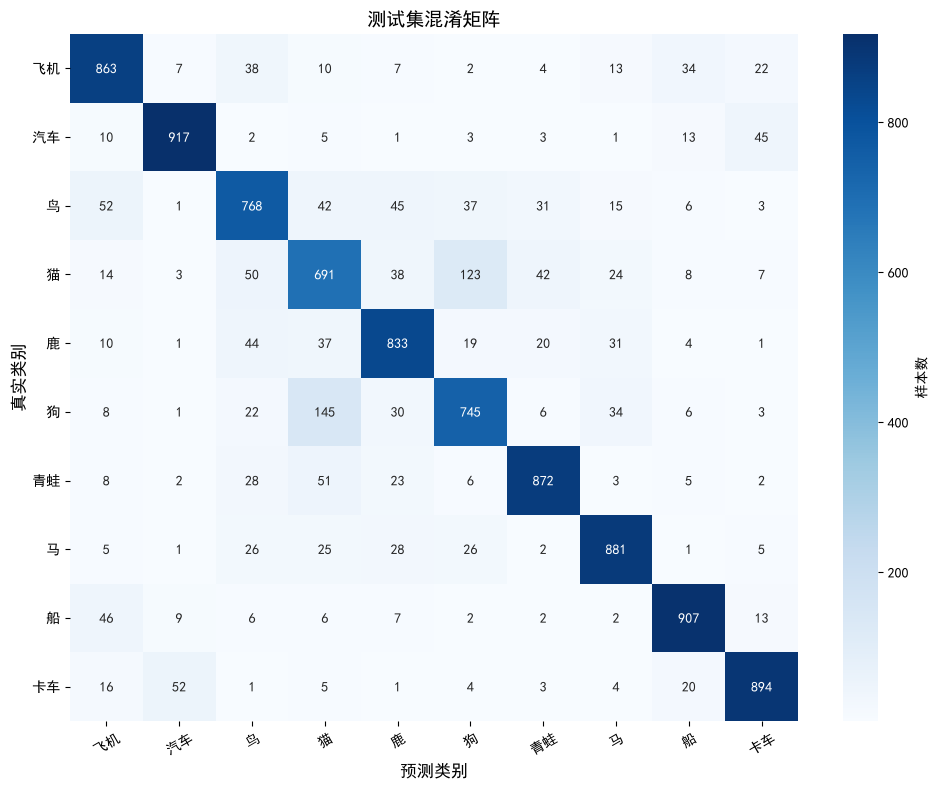

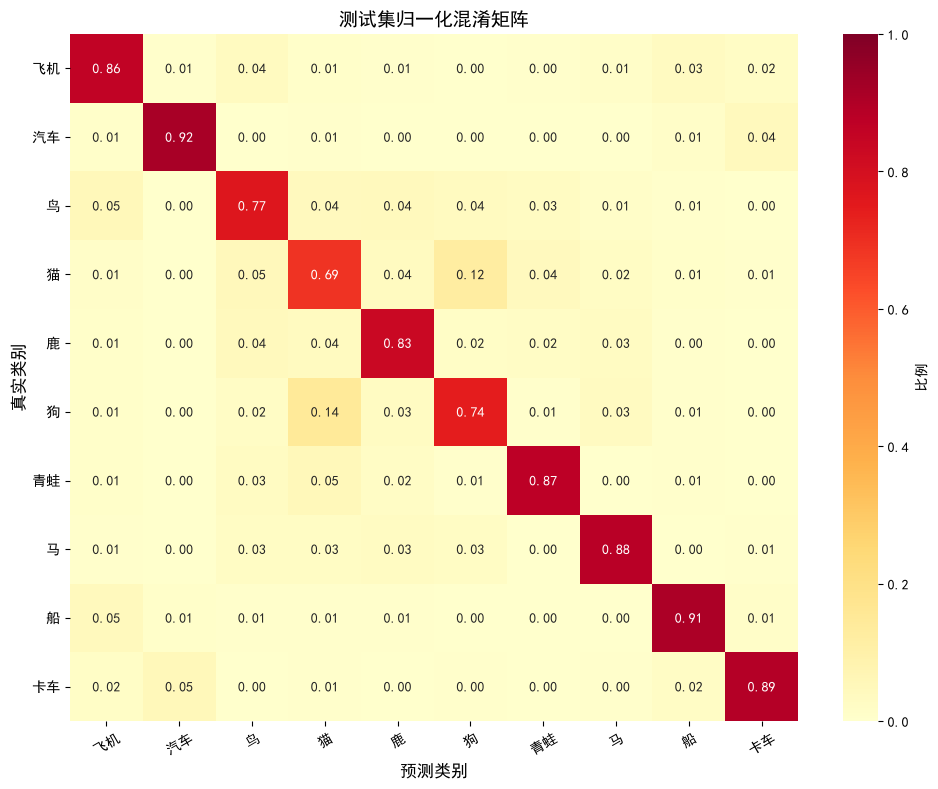

In [9]:
# 混淆矩阵
cm = confusion_matrix(all_labels_true, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES_CN, yticklabels=CLASS_NAMES_CN,
            cbar_kws={'label': '样本数'})
ax.set_xlabel('预测类别', fontsize=12)
ax.set_ylabel('真实类别', fontsize=12)
ax.set_title('测试集混淆矩阵', fontsize=14)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 归一化混淆矩阵
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES_CN, yticklabels=CLASS_NAMES_CN,
            vmin=0, vmax=1, cbar_kws={'label': '比例'})
ax.set_xlabel('预测类别', fontsize=12)
ax.set_ylabel('真实类别', fontsize=12)
ax.set_title('测试集归一化混淆矩阵', fontsize=14)
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_norm.png', dpi=150, bbox_inches='tight')
plt.show()


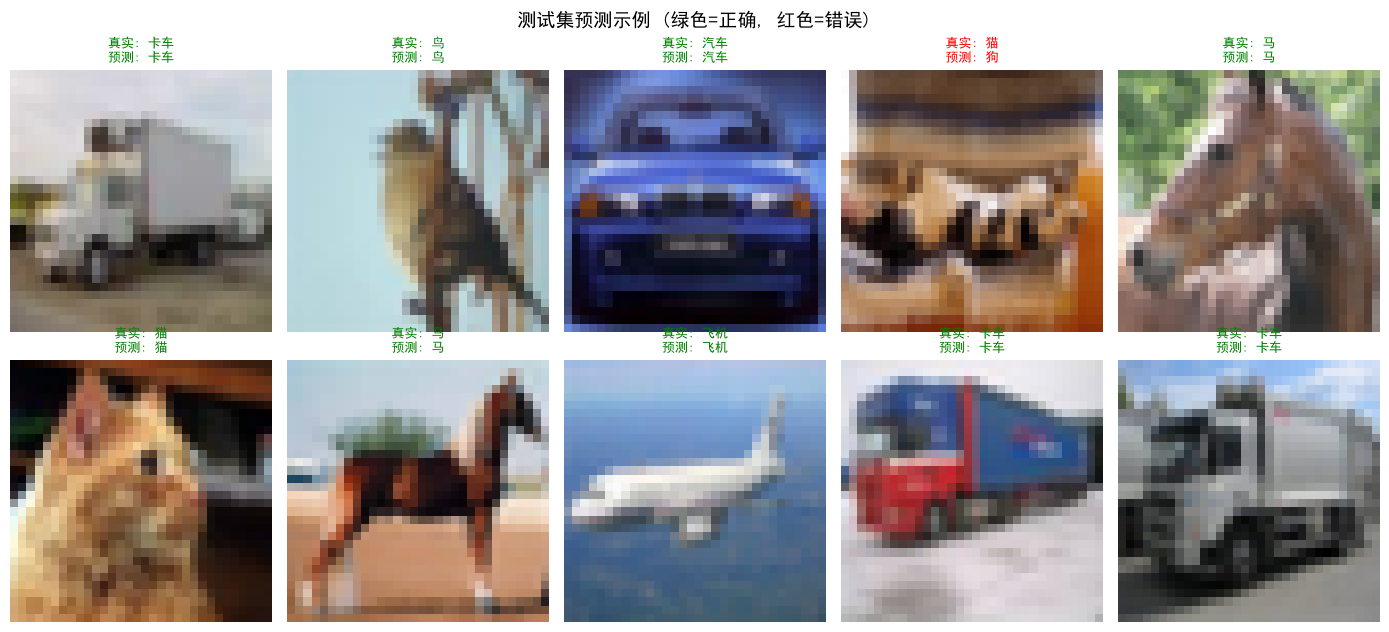

In [10]:
# 预测示例可视化
# 用未归一化的测试集来显示
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

model.eval()
test_indices = random.sample(range(len(raw_test)), 10)
fig, axes = plt.subplots(2, 5, figsize=(14, 6.5))
axes = axes.flatten()

for i, idx in enumerate(test_indices):
    img, true_label = raw_test[idx]
    # 对图片做归一化后推理
    img_tensor = test_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        _, pred_label = torch.max(output, 1)
    pred_label = pred_label.item()
    axes[i].imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    axes[i].set_title(f'真实: {CLASS_NAMES_CN[true_label]}\n预测: {CLASS_NAMES_CN[pred_label]}',
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('测试集预测示例 (绿色=正确, 红色=错误)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prediction_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 实验完成

所有图表和模型已保存到 `output/` 目录:
- `sample_images.png` — 样本示例
- `class_distribution.png` — 类别分布
- `training_curve.png` — 训练曲线
- `confusion_matrix.png` — 混淆矩阵
- `confusion_matrix_norm.png` — 归一化混淆矩阵
- `prediction_examples.png` — 预测示例
- `model.pth` — 模型权重（供 GUI 程序加载）
